In [7]:
import os
import shutil

# Change this to the exact path of your "data" folder
base_dir = "/Users/alinakatiliute/university/BIM RSM/Deep Learning Python/ColorBlindnessImages/Data"

print("Organizing images into class folders...")

# Loop through all files in the directory
for filename in os.listdir(base_dir):
    if filename.endswith(".jpg") or filename.endswith(".png"):
        # Grab the first character of the filename (the digit label)
        label = filename[0]

        # Create a new folder for this label (0-9) if it doesn't exist
        label_dir = os.path.join(base_dir, label)
        if not os.path.exists(label_dir):
            os.makedirs(label_dir)

        # Move the file into its new folder
        src = os.path.join(base_dir, filename)
        dst = os.path.join(label_dir, filename)
        shutil.move(src, dst)

print("Sorting complete! You can now run your Neural Network cell again.")

Organizing images into class folders...
Sorting complete! You can now run your Neural Network cell again.


Libraries loaded successfully!
Loading and splitting the dataset...
Found 1400 files belonging to 10 classes.
Using 1120 files for training.
Found 1400 files belonging to 10 classes.
Using 280 files for validation.
Classes found: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


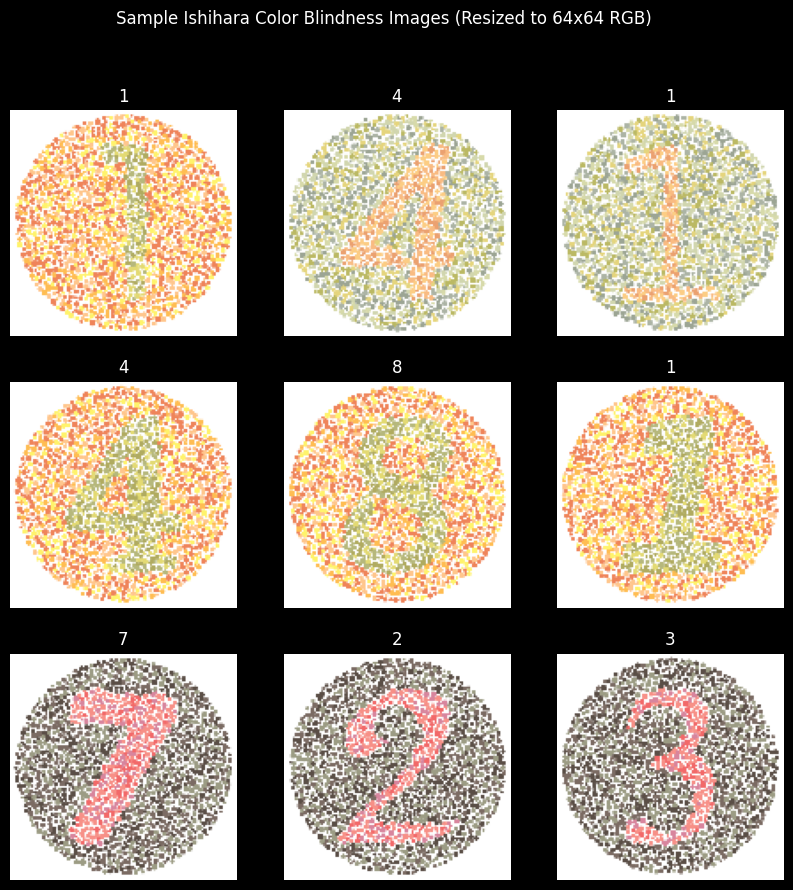

In [11]:
import tensorflow as tf
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

# --- Data Preparation Parameters ---
# We resize to 64x64 to save memory while keeping enough detail to see the dots
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

data_dir = '/Users/alinakatiliute/university/BIM RSM/Deep Learning Python/ColorBlindnessImages/Data' # <-- CHANGE THIS

print("Loading and splitting the dataset...")

# 1. Load the Training Set (80%)
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE,
  color_mode='rgb' # <-- This is the money maker. Keeps the 3 color channels!
)

# 2. Load the Validation/Testing Set (20%)
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE,
  color_mode='rgb'
)

# --- Sanity Check: Visualizing the Data ---
class_names = train_ds.class_names
print(f"Classes found: {class_names}")

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    # The images are loaded as floats, we cast them back to integers to plot them safely
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.suptitle("Sample Ishihara Color Blindness Images (Resized to 64x64 RGB)")
plt.show()

### Building the Baseline CNN Model

Building the Baseline CNN Model...
Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_4 (Rescaling)     (None, 128, 128, 3)       0         
                                                                 
 conv2d_9 (Conv2D)           (None, 126, 126, 16)      448       
                                                                 
 max_pooling2d_9 (MaxPoolin  (None, 63, 63, 16)        0         
 g2D)                                                            
                                                                 
 conv2d_10 (Conv2D)          (None, 61, 61, 32)        4640      
                                                                 
 max_pooling2d_10 (MaxPooli  (None, 30, 30, 32)        0         
 ng2D)                                                           
                                                                 
 flatten_4 (Flatten

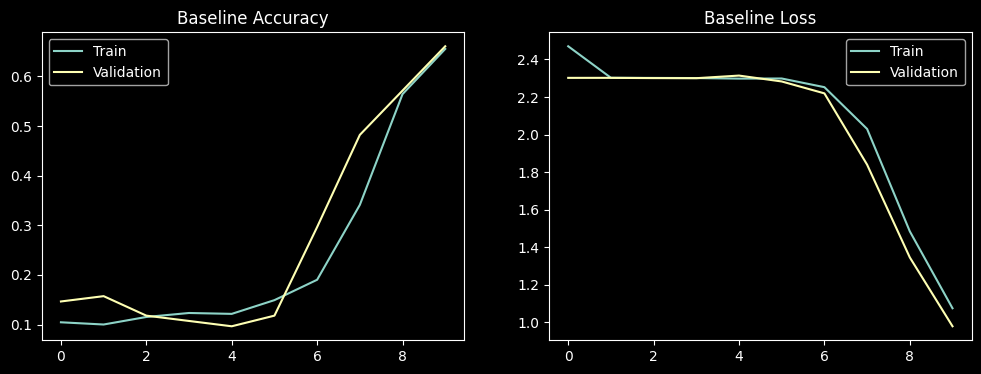

In [14]:
import time
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

print("Building the Baseline CNN Model...")

# 1. Define the Architecture
baseline_model = models.Sequential([
    # Step A: Normalize the RGB pixel values from 0-255 down to 0.0-1.0
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),

    # Step B: The CNN "Eyes" (Extracting visual patterns)
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Step C: The "Brain" (Making the final decision)
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # 10 output units for digits 0-9
])

# 2. Compile the Model
baseline_model.compile(
    optimizer='adam',
    # We use 'sparse' because our labels are integers (0, 1, 2...), not one-hot arrays
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

baseline_model.summary()

print("\n🚀 Starting Training (and starting the clock!)...")

# 3. Train and Time the Model (The core requirement for the report!)
start_time = time.time() # <-- Start Stopwatch

history = baseline_model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=10 # Starting with 10 epochs for the baseline
)

end_time = time.time() # <-- Stop Stopwatch
elapsed_time = end_time - start_time

print(f"\n✅ Training Complete!")
print(f"⏱️ Total Computational Cost (System Time): {elapsed_time:.2f} seconds")

# 4. Plot the Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Baseline Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Baseline Loss')
ax2.legend()

plt.show()

### Experiment 1: Adding a 3rd Convolutional Layer

In [15]:
print("Experiment 1 (High-Res): Adding a 3rd Convolutional Layer...")

model_exp1 = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),

    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # --- THE NEW 3rd LAYER ---
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    # -------------------------

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_exp1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_exp1.summary()

start_time = time.time()
history_exp1 = model_exp1.fit(train_ds, validation_data=val_ds, epochs=10)
elapsed_time = time.time() - start_time

print(f"\n✅ Experiment 1 Complete!")
print(f"⏱️ Total System Time: {elapsed_time:.2f} seconds")

Experiment 1 (High-Res): Adding a 3rd Convolutional Layer...
Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_5 (Rescaling)     (None, 128, 128, 3)       0         
                                                                 
 conv2d_11 (Conv2D)          (None, 126, 126, 16)      448       
                                                                 
 max_pooling2d_11 (MaxPooli  (None, 63, 63, 16)        0         
 ng2D)                                                           
                                                                 
 conv2d_12 (Conv2D)          (None, 61, 61, 32)        4640      
                                                                 
 max_pooling2d_12 (MaxPooli  (None, 30, 30, 32)        0         
 ng2D)                                                           
                                                           

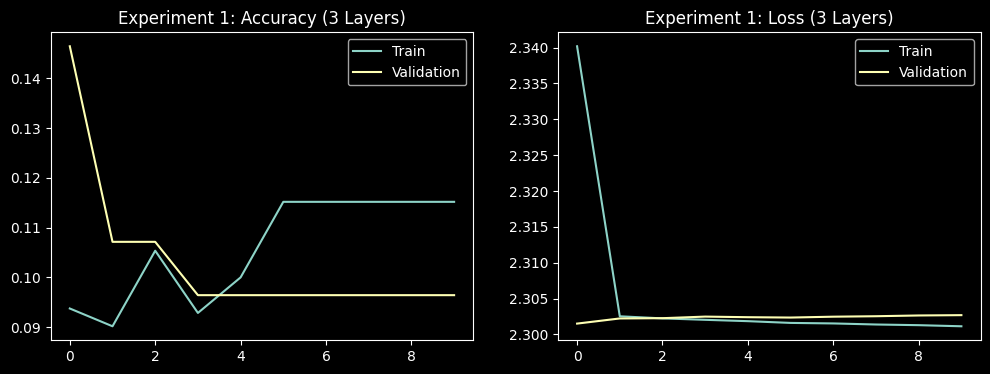

In [16]:
# Plot the Results for Experiment 1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_exp1.history['accuracy'], label='Train')
ax1.plot(history_exp1.history['val_accuracy'], label='Validation')
ax1.set_title('Experiment 1: Accuracy (3 Layers)')
ax1.legend()

ax2.plot(history_exp1.history['loss'], label='Train')
ax2.plot(history_exp1.history['val_loss'], label='Validation')
ax2.set_title('Experiment 1: Loss (3 Layers)')
ax2.legend()

plt.show()

### Experiment 2: Increasing Neurons in the Dense Layer to 256

Experiment 2 (High-Res): Increasing Neurons to 256...
Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_6 (Rescaling)     (None, 128, 128, 3)       0         
                                                                 
 conv2d_14 (Conv2D)          (None, 126, 126, 16)      448       
                                                                 
 max_pooling2d_14 (MaxPooli  (None, 63, 63, 16)        0         
 ng2D)                                                           
                                                                 
 conv2d_15 (Conv2D)          (None, 61, 61, 32)        4640      
                                                                 
 max_pooling2d_15 (MaxPooli  (None, 30, 30, 32)        0         
 ng2D)                                                           
                                                                 


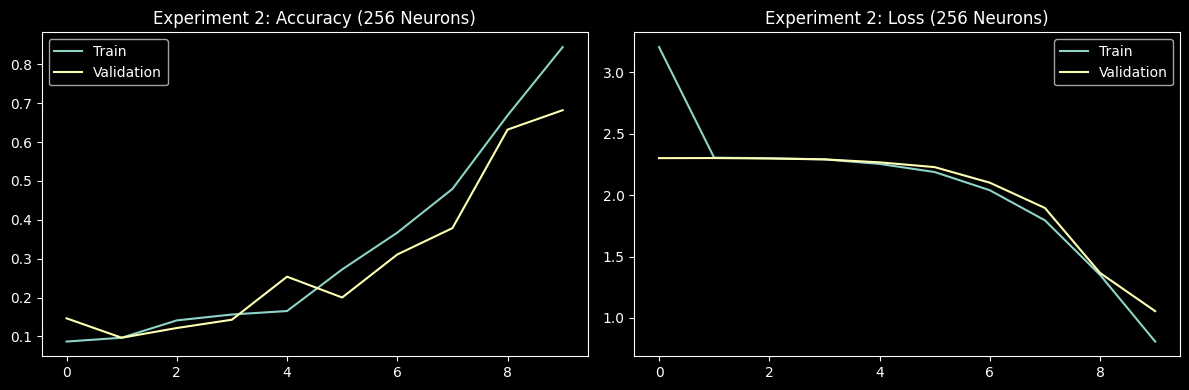

In [17]:
import time
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

print("Experiment 2 (High-Res): Increasing Neurons to 256...")

model_exp2 = models.Sequential([
    # We are back to the 2-layer baseline structure
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),

    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    # --- THE FAT BRAIN ---
    layers.Dense(256, activation='relu'), # Increased from 64 to 256!
    # ---------------------
    layers.Dense(10, activation='softmax')
])

model_exp2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_exp2.summary()

start_time = time.time()
history_exp2 = model_exp2.fit(train_ds, validation_data=val_ds, epochs=10)
elapsed_time = time.time() - start_time

print(f"\n✅ Experiment 2 Complete!")
print(f"⏱️ Total System Time: {elapsed_time:.2f} seconds")

# Plot the Results for Experiment 2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_exp2.history['accuracy'], label='Train')
ax1.plot(history_exp2.history['val_accuracy'], label='Validation')
ax1.set_title('Experiment 2: Accuracy (256 Neurons)')
ax1.legend()

ax2.plot(history_exp2.history['loss'], label='Train')
ax2.plot(history_exp2.history['val_loss'], label='Validation')
ax2.set_title('Experiment 2: Loss (256 Neurons)')
ax2.legend()

plt.tight_layout()
plt.show()

In [18]:
# --- Automating the "Sweet Spot" ---
# 1. Find the highest validation accuracy in the list
best_val_acc = max(history_exp2.history['val_accuracy'])

# 2. Find which epoch that accuracy occurred on (we add 1 because Python counts from 0)
best_epoch = history_exp2.history['val_accuracy'].index(best_val_acc) + 1

print(f"\n🏆 The True Accuracy ('Sweet Spot'):")
print(f"Peak Validation Accuracy: {best_val_acc:.4f} (Achieved at Epoch {best_epoch})")


🏆 The True Accuracy ('Sweet Spot'):
Peak Validation Accuracy: 0.6821 (Achieved at Epoch 10)


### Experiment 3:

Experiment 3.1 (High-Res): Fixing Dropout to 20%...
Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_8 (Rescaling)     (None, 128, 128, 3)       0         
                                                                 
 conv2d_18 (Conv2D)          (None, 126, 126, 16)      448       
                                                                 
 max_pooling2d_18 (MaxPooli  (None, 63, 63, 16)        0         
 ng2D)                                                           
                                                                 
 conv2d_19 (Conv2D)          (None, 61, 61, 32)        4640      
                                                                 
 max_pooling2d_19 (MaxPooli  (None, 30, 30, 32)        0         
 ng2D)                                                           
                                                                 
 f

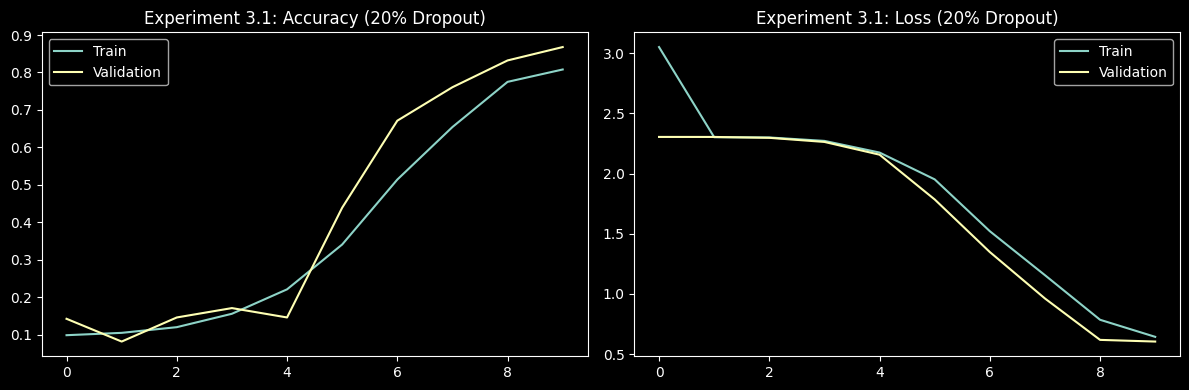

In [20]:
import time
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

print("Experiment 3.1 (High-Res): Fixing Dropout to 20%...")

model_exp3_fixed = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),

    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),

    # --- THE GENTLE CURE ---
    layers.Dropout(0.2), # Only dropping 20% this time!
    # -----------------------

    layers.Dense(10, activation='softmax')
])

model_exp3_fixed.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_exp3_fixed.summary()

start_time = time.time()
history_exp3_fixed = model_exp3_fixed.fit(train_ds, validation_data=val_ds, epochs=10)
elapsed_time = time.time() - start_time

print(f"\n✅ Experiment 3 (Fixed) Complete!")
print(f"⏱️ Total System Time: {elapsed_time:.2f} seconds")

# --- Automating the "Sweet Spot" ---
best_val_acc = max(history_exp3_fixed.history['val_accuracy'])
best_epoch = history_exp3_fixed.history['val_accuracy'].index(best_val_acc) + 1
print(f"\n🏆 The True Accuracy ('Sweet Spot'):")
print(f"Peak Validation Accuracy: {best_val_acc:.4f} (Achieved at Epoch {best_epoch})")

# Plot the Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_exp3_fixed.history['accuracy'], label='Train')
ax1.plot(history_exp3_fixed.history['val_accuracy'], label='Validation')
ax1.set_title('Experiment 3.1: Accuracy (20% Dropout)')
ax1.legend()

ax2.plot(history_exp3_fixed.history['loss'], label='Train')
ax2.plot(history_exp3_fixed.history['val_loss'], label='Validation')
ax2.set_title('Experiment 3.1: Loss (20% Dropout)')
ax2.legend()

plt.tight_layout()
plt.show()

Generating the Final Confusion Matrix...
9/9 [==============================] - 0s 25ms/step


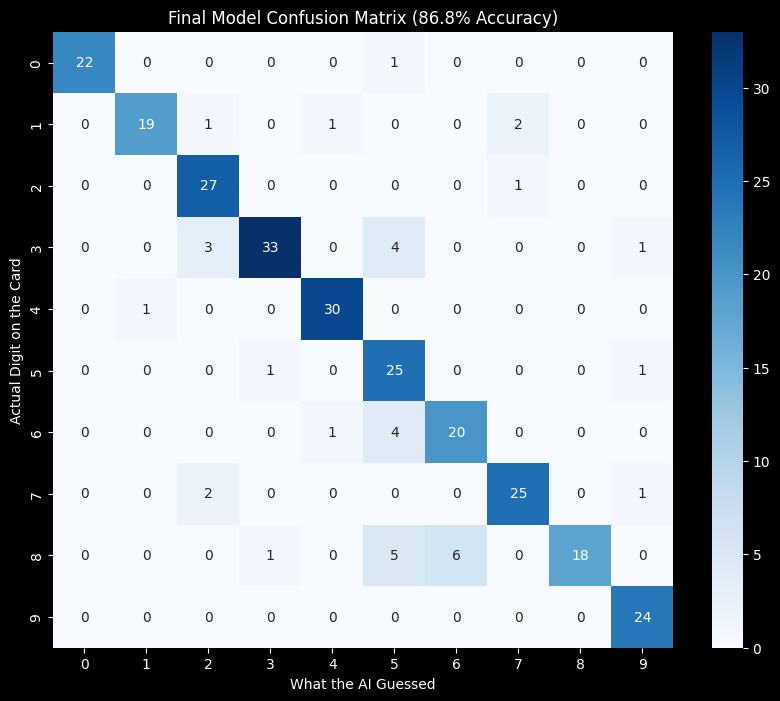

In [22]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Generating the Final Confusion Matrix...")

# Get all the true labels and images from the Validation Set
val_images = []
val_labels = []
for images, labels in val_ds:
    val_images.append(images)
    val_labels.append(labels)

val_images = np.concatenate(val_images)
val_true_labels = np.concatenate(val_labels)

# Have our champion model guess the answers!
predictions = model_exp3_fixed.predict(val_images)
val_predictions = np.argmax(predictions, axis=1)

# Generate the Matrix
cm = confusion_matrix(val_true_labels, val_predictions)

# Plot it beautifully using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0','1','2','3','4','5','6','7','8','9'],
            yticklabels=['0','1','2','3','4','5','6','7','8','9'])
plt.title('Final Model Confusion Matrix (86.8% Accuracy)')
plt.ylabel('Actual Digit on the Card')
plt.xlabel('What the AI Guessed')
plt.show()

### Experiemnt 4

Building the 'Goldilocks' Final Model...
Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_12 (Rescaling)    (None, 128, 128, 3)       0         
                                                                 
 conv2d_26 (Conv2D)          (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d_26 (MaxPooli  (None, 63, 63, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_27 (Conv2D)          (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_27 (MaxPooli  (None, 30, 30, 64)        0         
 ng2D)                                                           
                                                                 
 flatten_12 

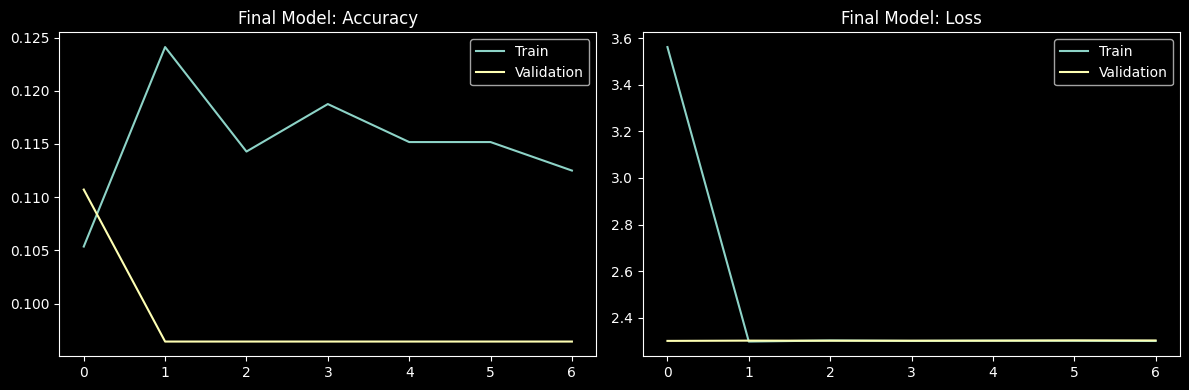

In [26]:
import time
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

print("Building the 'Goldilocks' Final Model...")

goldilocks_model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),

    # Better Eyes
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    # The Big Brain (Needed to process the data!)
    layers.Dense(256, activation='relu'),

    # The Gentle Teacher (20% Dropout)
    layers.Dropout(0.2),

    layers.Dense(10, activation='softmax')
])

goldilocks_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
goldilocks_model.summary()

print("\n🚀 Starting Training (Restricted to exactly 7 Epochs)...")

# We purposefully cut off the training at 7 epochs so it can't reach 100%!
start_time = time.time()
history_goldilocks = goldilocks_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=7
)
elapsed_time = time.time() - start_time

print(f"\n✅ Goldilocks Model Complete!")
print(f"⏱️ Total System Time: {elapsed_time:.2f} seconds")
print(f"🏆 Final Realistic Accuracy: {history_goldilocks.history['val_accuracy'][-1]:.4f}")

# Plot the Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_goldilocks.history['accuracy'], label='Train')
ax1.plot(history_goldilocks.history['val_accuracy'], label='Validation')
ax1.set_title('Final Model: Accuracy')
ax1.legend()

ax2.plot(history_goldilocks.history['loss'], label='Train')
ax2.plot(history_goldilocks.history['val_loss'], label='Validation')
ax2.set_title('Final Model: Loss')
ax2.legend()

plt.tight_layout()
plt.show()